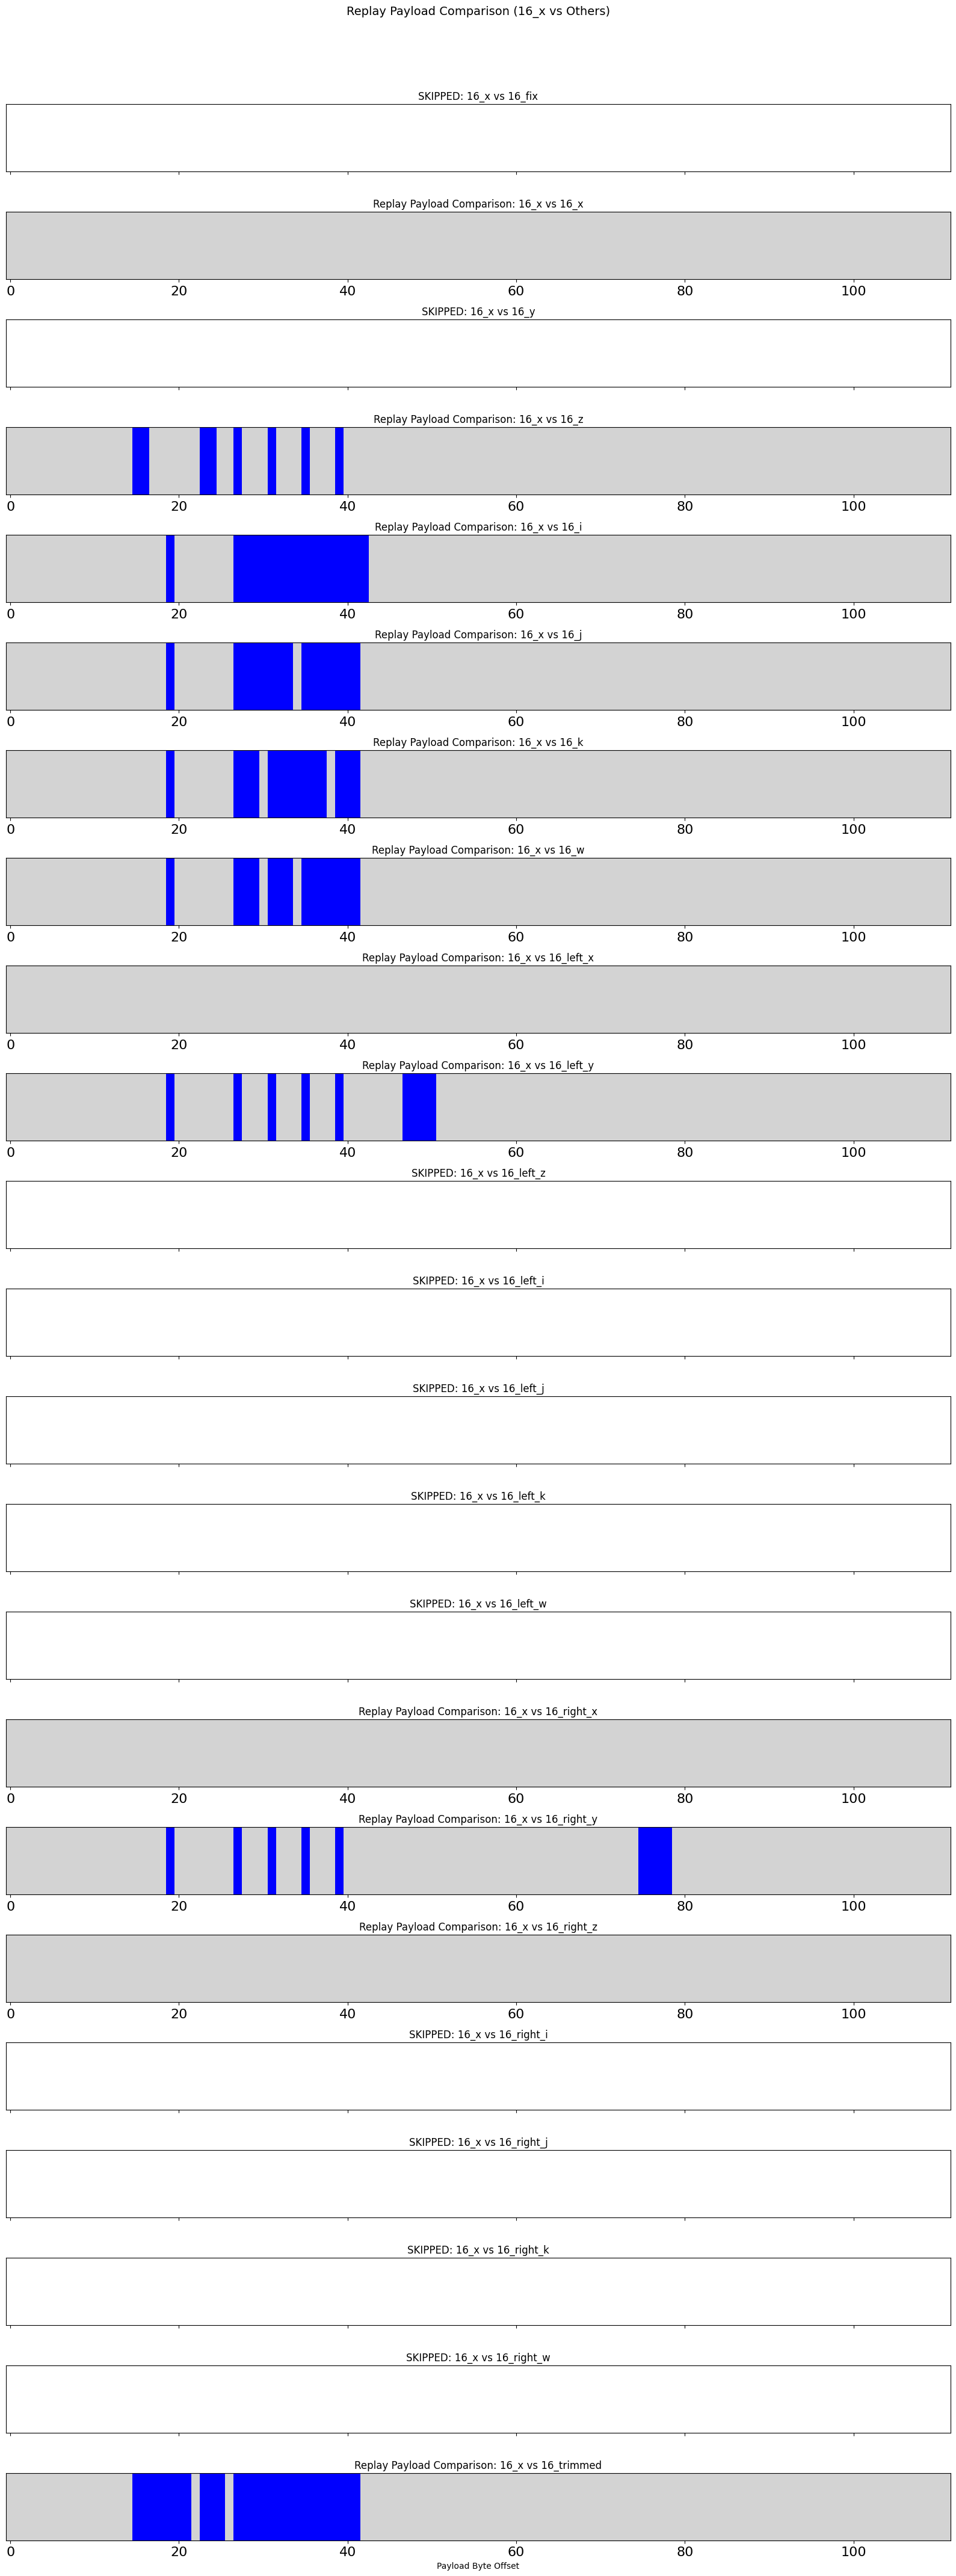

In [ ]:
import dpkt
import socket
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter
import binascii
import sys

# =================
# PCAP 필터링
# =================
port_marker = 55555

AppName = "Dungeon Free"
AppName = "UnityClient@Windows" # Zenith
# AppName = "HyperDash"
AppName = "pong_waves_vr"
AppName =  "Bigscreen"

try:
    df = pd.read_csv(f"{AppName}\\network_full_connections_{AppName}.csv")
except Exception:
    print("CSV 파일을 찾을 수 없습니다.")

# Protocol이 UDP인 행만 필터링
ports = set(
    df.loc[df["Protocol"] == "UDP", "LocalPort"]
    .dropna()            # NaN 제거
    .astype(int)         # 포트 번호 정수 변환
)

if AppName == "TalesofEscape":
    ports = {52428}  # Tales of Escape의 경우 수동 설정
if AppName == "RockLifeVR":
    ports = {50448}  # Rock Life VR의 경우 수동 설정
if AppName == "VAIL":
    ports = {63251}  # VAIL의 경우 수동 설정
if AppName == "VAIL_left":
    ports = {63894} # VAIL의 경우 수동 설정 left
if AppName == "VAIL_right":
    ports = {54425} # VAIL의 경우 수동 설정 right

# =================
# log
# =================
log_file = open(f"{AppName}\\filtering_log.txt", "w", encoding="utf-8")
sys.stdout = log_file

with open(f"{AppName}\\exp1.pcap", "rb") as f:
    pcap = dpkt.pcapng.Reader(f)

    with open(f"{AppName}\\filtered2.pcap", "wb") as out:
        writer = dpkt.pcapng.Writer(out)

        it = iter(pcap)
        while True:
            try:
                ts, buf = next(it)
            except StopIteration:
                break
            except dpkt.NeedData:
                continue

            # Ethernet 프레임 파싱
            try: 
                eth = dpkt.ethernet.Ethernet(buf)
            except Exception:
                continue

            # =================
            # VLAN 태그 처리
            # =================
            data = eth.data
            if isinstance(data, dpkt.ethernet.VLANtag8021Q):
                data = data.data
            
            # IPv4만 처리
            if not isinstance(data, dpkt.ip.IP):
                continue

            ip = data
            if ip.p != dpkt.ip.IP_PROTO_UDP:
                continue

            udp = ip.data
            if udp.sport in ports or udp.dport == port_marker:
                writer.writepkt(buf, ts)

# =================
# 프레임 길이 기반 필터링
# =================
input_pcap = f"{AppName}\\filtered2.pcap"
output_pcap = f"{AppName}\\filtered_freq.pcap"

# 1️⃣ 프레임 길이 빈도 계산
lengths = []
packets = []

with open(input_pcap, "rb") as f:
    try:
        reader = dpkt.pcap.Reader(f)
    except ValueError:
        f.seek(0)
        reader = dpkt.pcapng.Reader(f)

    for ts, buf in reader:
        lengths.append(len(buf))
        packets.append((ts, buf))

# 2️⃣ 최빈 프레임 길이
most_common_len, _ = Counter(lengths).most_common(1)[0]
# most_common_len, _ = Counter(lengths).most_common(2)[1]
if AppName == "TalesofEscape":
    most_common_len = 152
if AppName == "UnityClient@Windows":
    most_common_len = 111
if AppName == "Bigscreen":
    most_common_len = 96
if AppName == "pong_waves_vr":
    most_common_len = 154

print("Most common frame length:", most_common_len)
# 3️⃣ 해당 길이 패킷만 저장
with open(output_pcap, "wb") as out:
    writer = dpkt.pcap.Writer(out)
    for ts, buf in packets:
        eth = dpkt.ethernet.Ethernet(buf)
        ip = eth.data
        udp = ip.data
        if len(buf) == most_common_len or udp.dport == port_marker:
            writer.writepkt(buf, ts)

length_counter = Counter(lengths)

for length, count in length_counter.items():
    print(f"Length {length:5d} bytes : {count}")



# ==================
# PCAP -> TXT 덤프
# ==================
with open(f"{AppName}\\filtered_freq.pcap", "rb") as f:
    pcap = dpkt.pcap.Reader(f)

    with open(f"{AppName}\\packets_analysis.txt", "w", encoding="utf-8") as out:
        for i, (ts, buf) in enumerate(pcap, 1):
            out.write(f"Packet {i}\n")
            out.write(f"Timestamp: {ts}\n")
            out.write(binascii.hexlify(buf).decode() + "\n\n")

# ==================
# PCAP -> CSV 분석
# ==================
# 5️⃣ 패킷의 각 부분을 별도의 열로 분할
# raw hex임

def mac_addr(mac):
    return ":".join(f"{b:02x}" for b in mac)

input_pcap = f"{AppName}\\filtered_freq.pcap"
output_csv = f"{AppName}\\packets_analysis.csv"

with open(input_pcap, "rb") as f:
    pcap = dpkt.pcap.Reader(f)

    with open(output_csv, "w", newline="", encoding="utf-8") as out:
        writer = csv.writer(out)
        writer.writerow([
            "pkt_no",
            "timestamp",
            "eth_dst",
            "eth_src",
            "eth_type",
            "ip_src",
            "ip_dst",
            "ip_proto",
            "udp_sport",
            "udp_dport",
            "beacon_type",
            "eth_hex",
            "ip_hex",
            "udp_hex",
            "payload_hex"
        ])

        for i, (ts, buf) in enumerate(pcap, 1):
            eth = dpkt.ethernet.Ethernet(buf)

            # Ethernet
            eth_dst = mac_addr(eth.dst)
            eth_src = mac_addr(eth.src)
            eth_type = hex(eth.type)

            # 기본값
            ip_src = ip_dst = ip_proto = ""
            udp_sport = udp_dport = ""
            payload = b""
            beacon_type = ""

            if isinstance(eth.data, dpkt.ip.IP):
                ip = eth.data
                ip_src = socket.inet_ntoa(ip.src)
                ip_dst = socket.inet_ntoa(ip.dst)
                ip_proto = ip.p

                if ip.p == dpkt.ip.IP_PROTO_UDP:
                    udp = ip.data
                    udp_sport = udp.sport
                    udp_dport = udp.dport
                    payload = udp.data

                    if udp.dport == port_marker:
                        try:
                            beacon_type = payload.decode("ascii", errors="replace")
                        except Exception:
                            beacon_type = ""
                    
            offset = 0

            # Ethernet (14B) - Destination MAC (6B), Source MAC (6B), EtherType (2B)
            #  나중에 VLAN 태그가 있는 경우를 고려할 수 있음 - VLAN 태그는 4B - Ethernet 헤더는 18B
            eth_hex = binascii.hexlify(buf[offset:offset+14]).decode()
            offset += 14

            # IP header length (ihl * 4)
            ihl = (buf[offset] & 0x0F) * 4
            ip_hex = binascii.hexlify(buf[offset:offset+ihl]).decode()
            offset += ihl

            # UDP header (8B)
            udp_hex = binascii.hexlify(buf[offset:offset+8]).decode()
            offset += 8

            # Payload (rest)
            payload_hex = binascii.hexlify(buf[offset:]).decode()

            writer.writerow([
                i,
                ts,
                eth_dst,
                eth_src,
                eth_type,
                ip_src,
                ip_dst,
                ip_proto,
                udp_sport,
                udp_dport,
                beacon_type,
                eth_hex,
                ip_hex,
                udp_hex,
                payload_hex
            ])


# ==================
# 페이로드 변화 분석
# ==================
CSV_PATH = f"{AppName}\\packets_analysis.csv"
PORT = "55555"

START_KEY = "SYNC_BEACON|replay_start|16_fix"
END_KEY   = "SYNC_BEACON|replay_end|16_fix"

start_ts = None
end_ts = None

rows = []

# 1️⃣ CSV 전체 로드
with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# 2️⃣ replay_start / replay_end timestamp 찾기
# for row in rows:
#     if row["udp_dport"] != PORT:
#         continue

#     if START_KEY in row["beacon_type"]:
#         start_ts = float(row["timestamp"])

#     if END_KEY in row["beacon_type"] and start_ts is not None:
#         end_ts = float(row["timestamp"])
#         break

# if start_ts is None or end_ts is None:
#     raise RuntimeError("replay_start or replay_end not found")

# print("Replay window:", start_ts, "~", end_ts)

# # 3️⃣ 해당 시간 구간의 '일반 패킷' payload 수집
# payloads = []


axes = ["x", "y", "z", "i", "j", "k", "w"]

REPLAY_IDS = ["16_fix", "16_x","16_y",
              "16_z","16_i","16_j","16_k","16_w",
              *(f"16_left_{axis}" for axis in axes for _ in range(1)),
              *(f"16_right_{axis}" for axis in axes for _ in range(1))]


def contiguous_ranges_from_mask(mask):
    """True가 연속된 구간을 (start, end) 리스트로 반환 (end 포함)"""
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []

    splits = np.where(np.diff(idx) != 1)[0] + 1
    groups = np.split(idx, splits)
    return [(int(g[0]), int(g[-1])) for g in groups]


def get_change_map(rows, replay_id, PORT):
    START_KEY = f"SYNC_BEACON|replay_start|{replay_id}"
    END_KEY   = f"SYNC_BEACON|replay_end|{replay_id}"

    start_ts = end_ts = None

    for row in rows:
        if row["udp_dport"] != PORT:
            continue
        if START_KEY in row["beacon_type"] and start_ts is None:
            start_ts = float(row["timestamp"])
        if END_KEY in row["beacon_type"] and start_ts is not None:
            end_ts = float(row["timestamp"])
            break

    if start_ts is None or end_ts is None:
        return None

    payloads = []
    for row in rows:
        ts = float(row["timestamp"])
        if not (start_ts + 0.5 < ts < end_ts - 0.5):
            continue
        if row["beacon_type"].startswith("SYNC_BEACON"):
            continue
        if row["payload_hex"]:
            payloads.append(bytes.fromhex(row["payload_hex"]))

    if not payloads:
        return None

    min_len = min(len(p) for p in payloads)
    change_map = np.zeros(min_len, dtype=int)

    for i in range(min_len):
        if len({p[i] for p in payloads}) > 1:
            change_map[i] = 1

    return change_map


def find_first_valid_fix(rows, replay_ids, PORT):
    for rid in replay_ids:
        cmap = get_change_map(rows, rid, PORT)
        if cmap is not None:
            print(f"[AUTO FIX] using first valid fix: {rid}")
            return rid
    return None

fix_name = "16_fix"

change_names = ["16_fix", "16_x","16_y", "16_z","16_i","16_j","16_k","16_w",
              "16_left_x", "16_left_y", "16_left_z", "16_left_i", "16_left_j", "16_left_k", "16_left_w",
                "16_right_x", "16_right_y", "16_right_z", "16_right_i", "16_right_j", "16_right_k", "16_right_w","16_trimmed"]
fix_name = find_first_valid_fix(rows, change_names, PORT)

num_plots = len(change_names)
fig, axes = plt.subplots(
    num_plots, 1,
    figsize=(16, 2 * num_plots),
    sharex=True
)
# change_names가 1개일 때 대비
if num_plots == 1:
    axes = [axes]

fix_map1 = get_change_map(rows, fix_name, PORT)
for idx, change_name in enumerate(change_names):

    if change_name == fix_name:
        x_map = fix_map1
    else:
        x_map = get_change_map(rows, change_name, PORT)
    # fix_map = get_change_map(rows, fix_name, PORT)
    # x_map   = get_change_map(rows, change_name, PORT)

    if fix_map1 is None or x_map is None:
        # print(idx, fix_name, change_name)
        # raise RuntimeError("change_map not found")
        print(f"[SKIP] change_map not found: {fix_name} vs {change_name}")
        ax = axes[idx]
        ax.set_yticks([])
        ax.set_title(f"SKIPPED: {fix_name} vs {change_name}")
        continue


    min_len = min(len(fix_map1), len(x_map))
    # fix_map = fix_map1[:min_len]
    fix_map = fix_map1[:min_len]
    x_map   = x_map[:min_len]

    ax = axes[idx]

    # ============================
    # ✅ 16_fix vs 16_fix 인 경우
    # ============================
    if change_name == fix_name:
        # fix_map 자체가 0/1 이므로 그대로 시각화
        compare_map = fix_map

        cmap = ListedColormap([
            "lightgray",  # 0: 고정
            "red"         # 1: 변화
        ])

        ax.imshow(compare_map.reshape(1, -1), cmap=cmap, aspect="auto")
        ax.set_yticks([])
        ax.tick_params(axis="x", labelbottom=True)
    
    else:
        # 0 = 동일, 1 = 둘 다 변화, 2 = 서로 다름
        compare_map = np.zeros(min_len, dtype=int)

        for i in range(min_len):
            if fix_map[i] == 0 and x_map[i] == 0:
                compare_map[i] = 0        # ⚪ 공통 고정
            elif fix_map[i] == 1 and x_map[i] == 1:
                compare_map[i] = 1        # 🔴 공통 변화
            elif fix_map[i] == 1 and x_map[i] == 0:
                compare_map[i] = 2        # darkgrey 사라짐
            elif fix_map[i] == 0 and x_map[i] == 1:
                compare_map[i] = 3        # 🔵 생김
        from matplotlib.colors import ListedColormap

        # 🔵 x만 변화한 byte offset range 계산 (value == 3)
        blue_mask = (compare_map == 3)
        blue_ranges = contiguous_ranges_from_mask(blue_mask)

        if blue_ranges:
            ranges_str = ", ".join(f"{s}-{e}" for s, e in blue_ranges)
            print(f"[{change_name}] BLUE (x-only change): {ranges_str}")
        else:
            print(f"[{change_name}] BLUE (x-only change): 없음")


        cmap = ListedColormap([
            "lightgray",  # 0: 둘 다 고정
            "red",        # 1: 둘 다 변화
            "black",   # 2: fix만 변화
            "blue"        # 3: x만 변화 (중요!)
        ])

        # fig, ax = plt.subplots(figsize=(14, 2))
        ax = axes[idx]

        ax.imshow(
            compare_map.reshape(1, -1),
            cmap=cmap,
            aspect="auto"
        )

        

    ax.set_yticks([])
    # ax.set_xlabel("Payload Byte Offset")
    ax.set_title("Replay Payload Comparison: " + fix_name + " vs " + change_name)
    ax.tick_params(axis="x", labelbottom=True, labelsize=16)   # ✅ sharex여도 위에 라벨 표시되게

    plt.tight_layout(pad=2.0)

    # ✅ subplot 하나를 따로 저장 (해당 axes 영역만 crop)
    fig.canvas.draw()  # 렌더링 강제

    fname = f"{AppName}\\compare_{fix_name}_vs_{change_name}.png"
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

    # fig.savefig(fname, dpi=300, bbox_inches=extent.expanded(1.02, 1.55))
    print("Saved:", fname)
    #########################
    
    # plt.show()
    if idx == num_plots - 1:
        ax.set_xlabel("Payload Byte Offset")
    
        
plt.suptitle(
    f"Replay Payload Comparison ({fix_name} vs Others)",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])

output_png = f"{AppName}\\replay_payload_comparison.png"
plt.savefig(output_png, dpi=300)
plt.show()
plt.close()

print("Saved:", output_png)

sys.stdout.close()
sys.stdout = sys.__stdout__

In [ ]:
import os
from collections import Counter
import dpkt
import csv
import socket
import binascii

# ==========================
# helper: MAC format
# ==========================
def mac_addr(mac):
    return ":".join(f"{b:02x}" for b in mac)

# ==========================
# 1) replay 구간 찾기
# ==========================
def find_replay_window_from_csv(rows, replay_id, PORT="55555"):
    START_KEY = f"SYNC_BEACON|replay_start|{replay_id}"
    END_KEY   = f"SYNC_BEACON|replay_end|{replay_id}"

    start_ts = None
    end_ts = None

    for row in rows:
        if row["udp_dport"] != PORT:
            continue

        b = row.get("beacon_type", "")

        if START_KEY in b and start_ts is None:
            start_ts = float(row["timestamp"])

        if END_KEY in b and start_ts is not None:
            end_ts = float(row["timestamp"])
            break

    if start_ts is None or end_ts is None:
        return None

    return (start_ts, end_ts)

# ==========================
# 2) replay window 내부 packet list 수집
# ==========================
def collect_packets_in_window(pcap_path, start_ts, end_ts):
    packets = []
    lengths = []

    with open(pcap_path, "rb") as f:
        # pcap/pcapng 자동 처리
        try:
            reader = dpkt.pcap.Reader(f)
        except ValueError:
            f.seek(0)
            reader = dpkt.pcapng.Reader(f)

        for ts, buf in reader:
            if start_ts <= ts <= end_ts:
                packets.append((ts, buf))
                lengths.append(len(buf))

    return packets, lengths

# ==========================
# 3) replay window별 최빈 길이 filtering -> PCAP 저장
# ==========================
def save_filtered_by_most_common_len(packets, lengths, out_pcap_path):
    if not packets or not lengths:
        return None, None, None, None
    common = Counter(lengths).most_common(2)
    # 1등
    most_common_len, most_common_cnt = common[0]
    # 2등
    if len(common) > 1:
        second_common_len, second_common_cnt = common[1]
    else:
        second_common_len, second_common_cnt = None, None

    return most_common_len, most_common_cnt, second_common_len, second_common_cnt

# ==========================================================
# ✅ 메인 실행: replay_id별 filtered_freq_by_len + csv 저장
# ==========================================================
AppDir = AppName
os.makedirs(AppDir, exist_ok=True)

CSV_PATH = f"{AppName}\\packets_analysis.csv"
PCAP_PATH = f"{AppName}\\filtered2.pcap"   # replay window는 여기서 뽑는 걸 권장
PORT_STR = "55555"

# 1) CSV load
with open(CSV_PATH, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

# 2) replay IDs (네가 쓰던 것)
axes = ["x", "y", "z", "i", "j", "k", "w"]
REPLAY_IDS = [
    "16_fix", "16_x", "16_y", "16_z", "16_i", "16_j", "16_k", "16_w",
    *(f"16_left_{axis}" for axis in axes),
    *(f"16_right_{axis}" for axis in axes),
]

summary_rows = []  # 결과 요약용

for replay_id in REPLAY_IDS:
    win = find_replay_window_from_csv(rows, replay_id, PORT=PORT_STR)
    if win is None:
        print(f"[SKIP] replay window not found: {replay_id}")
        continue

    start_ts, end_ts = win
    # 기존 네 코드처럼 여유를 주고 싶으면 여기서 조정:
    # start_ts2 = start_ts + 0.5
    # end_ts2   = end_ts - 0.5
    start_ts2 = start_ts + 0.5
    end_ts2   = end_ts - 0.5

    packets, lengths = collect_packets_in_window(PCAP_PATH, start_ts2, end_ts2)

    if not packets:
        print(f"[SKIP] no packets in window: {replay_id}")
        continue

    out_pcap = f"{AppName}\\filtered_freq_by_len_{replay_id}.pcap"
    mlen, mcnt, slen, scnt = save_filtered_by_most_common_len(packets, lengths, out_pcap)
    if mlen is None:
        print(f"[SKIP] could not determine most common len: {replay_id}")
        continue

    out_csv = f"{AppName}\\packets_analysis_{replay_id}.csv"

    print(f"[OK] {replay_id}: most_common_len={mlen}, saved pcap/csv")

    summary_rows.append({
        "replay_id": replay_id,
        "start_ts": start_ts2,
        "end_ts": end_ts2,
        "packets_in_window": len(packets),
        "most_common_len": mlen,
        "most_common_cnt": mcnt,

        "second_common_len": slen,
        "second_common_cnt": scnt,
        "out_pcap": out_pcap,
        "out_csv": out_csv
    })

# 요약 CSV 저장도 가능
summary_csv = f"{AppName}\\filtered_freq_by_len_summary.csv"
with open(summary_csv, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()) if summary_rows else [])
    if summary_rows:
        w.writeheader()
        w.writerows(summary_rows)

print("[DONE] saved:", summary_csv)


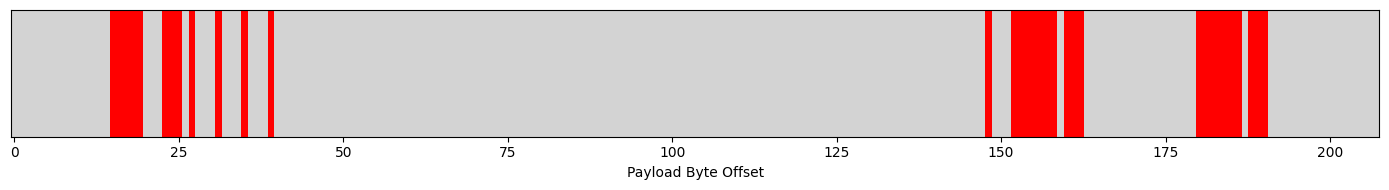

In [8]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# === fix_x만 그리기 ===
TARGET_ID = "16_x"          # 또는 "16_fix_x" 네 데이터에 맞게
PORT = "55555"

START_KEY = f"SYNC_BEACON|replay_start|{TARGET_ID}"
END_KEY   = f"SYNC_BEACON|replay_end|{TARGET_ID}"

start_ts = None
end_ts = None

# 1) replay_start / replay_end timestamp 찾기
for row in rows:
    if row["udp_dport"] != PORT:
        continue

    if START_KEY in row["beacon_type"]:
        start_ts = float(row["timestamp"])

    if END_KEY in row["beacon_type"] and start_ts is not None:
        end_ts = float(row["timestamp"])
        break

if start_ts is None or end_ts is None:
    print(f"[SKIP] {TARGET_ID} (start/end not found)")
else:
    # 2) 해당 시간 구간 payload 수집
    payloads = []
    for row in rows:
        ts = float(row["timestamp"])

        if not (start_ts + 0.5 < ts < end_ts - 0.5):
            continue

        # beacon은 제외
        if row["beacon_type"].startswith("SYNC_BEACON"):
            continue

        payload_hex = row["payload_hex"]
        if not payload_hex:
            continue

        payloads.append(bytes.fromhex(payload_hex))

    if not payloads:
        print(f"[SKIP] {TARGET_ID} (no payloads)")
    else:
        # 3) 길이 통일
        min_len = min(len(p) for p in payloads)
        payloads = [p[:min_len] for p in payloads]

        # 4) change_map 생성
        change_map = np.zeros(min_len, dtype=int)
        for i in range(min_len):
            if len({p[i] for p in payloads}) > 1:
                change_map[i] = 1

        # 5) 시각화
        fig, ax = plt.subplots(figsize=(14, 2))
        cmap = ListedColormap(["lightgray", "red"])

        ax.imshow(change_map.reshape(1, -1), cmap=cmap, aspect="auto")

        ax.set_yticks([])
        ax.set_xlabel("Payload Byte Offset")
        # ax.set_title(f"Replay Payload Change Map : {TARGET_ID}")

        plt.tight_layout()
        plt.savefig(f"{AppName}\\replay_payload_change_map_{TARGET_ID}.png", dpi=300)
        plt.show()

plt.close()


In [ ]:
import dpkt
import socket
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter
import binascii
import sys

# =================
# PCAP 필터링
# =================
port_marker = 55555

AppName = "Dungeon Free"
AppName = "UnityClient@Windows" # Zenith
# AppName = "HyperDash"
AppName = "pong_waves_vr"
AppName =  "Bigscreen"

try:
    df = pd.read_csv(f"{AppName}\\network_full_connections_{AppName}.csv")
except Exception:
    print("CSV 파일을 찾을 수 없습니다.")

# Protocol이 UDP인 행만 필터링
ports = set(
    df.loc[df["Protocol"] == "UDP", "LocalPort"]
    .dropna()            # NaN 제거
    .astype(int)         # 포트 번호 정수 변환
)

if AppName == "TalesofEscape":
    ports = {52428}  # Tales of Escape의 경우 수동 설정
if AppName == "RockLifeVR":
    ports = {50448}  # Rock Life VR의 경우 수동 설정
if AppName == "VAIL":
    ports = {63251}  # VAIL의 경우 수동 설정
if AppName == "VAIL_left":
    ports = {63894} # VAIL의 경우 수동 설정 left
if AppName == "VAIL_right":
    ports = {54425} # VAIL의 경우 수동 설정 right

# =================
# log
# =================
log_file = open(f"{AppName}\\filtering_log.txt", "w", encoding="utf-8")
sys.stdout = log_file

with open(f"{AppName}\\exp1.pcap", "rb") as f:
    pcap = dpkt.pcapng.Reader(f)

    with open(f"{AppName}\\filtered2.pcap", "wb") as out:
        writer = dpkt.pcapng.Writer(out)

        it = iter(pcap)
        while True:
            try:
                ts, buf = next(it)
            except StopIteration:
                break
            except dpkt.NeedData:
                continue

            # Ethernet 프레임 파싱
            try: 
                eth = dpkt.ethernet.Ethernet(buf)
            except Exception:
                continue

            # =================
            # VLAN 태그 처리
            # =================
            data = eth.data
            if isinstance(data, dpkt.ethernet.VLANtag8021Q):
                data = data.data
            
            # IPv4만 처리
            if not isinstance(data, dpkt.ip.IP):
                continue

            ip = data
            if ip.p != dpkt.ip.IP_PROTO_UDP:
                continue

            udp = ip.data
            if udp.sport in ports or udp.dport == port_marker:
                writer.writepkt(buf, ts)

# =================
# 프레임 길이 기반 필터링
# =================
input_pcap = f"{AppName}\\filtered2.pcap"
output_pcap = f"{AppName}\\filtered_freq.pcap"

# 1️⃣ 프레임 길이 빈도 계산
lengths = []
packets = []

with open(input_pcap, "rb") as f:
    try:
        reader = dpkt.pcap.Reader(f)
    except ValueError:
        f.seek(0)
        reader = dpkt.pcapng.Reader(f)

    for ts, buf in reader:
        lengths.append(len(buf))
        packets.append((ts, buf))

# 2️⃣ 최빈 프레임 길이
most_common_len, _ = Counter(lengths).most_common(1)[0]
# most_common_len, _ = Counter(lengths).most_common(2)[1]
if AppName == "TalesofEscape":
    most_common_len = 152
if AppName == "UnityClient@Windows":
    most_common_len = 111
if AppName == "Bigscreen":
    most_common_len = 96
if AppName == "pong_waves_vr":
    most_common_len = 154

print("Most common frame length:", most_common_len)
# 3️⃣ 해당 길이 패킷만 저장
with open(output_pcap, "wb") as out:
    writer = dpkt.pcap.Writer(out)
    for ts, buf in packets:
        eth = dpkt.ethernet.Ethernet(buf)
        ip = eth.data
        udp = ip.data
        if len(buf) == most_common_len or udp.dport == port_marker:
            writer.writepkt(buf, ts)

length_counter = Counter(lengths)

for length, count in length_counter.items():
    print(f"Length {length:5d} bytes : {count}")



# ==================
# PCAP -> TXT 덤프
# ==================
with open(f"{AppName}\\filtered_freq.pcap", "rb") as f:
    pcap = dpkt.pcap.Reader(f)

    with open(f"{AppName}\\packets_analysis.txt", "w", encoding="utf-8") as out:
        for i, (ts, buf) in enumerate(pcap, 1):
            out.write(f"Packet {i}\n")
            out.write(f"Timestamp: {ts}\n")
            out.write(binascii.hexlify(buf).decode() + "\n\n")

# ==================
# PCAP -> CSV 분석
# ==================
# 5️⃣ 패킷의 각 부분을 별도의 열로 분할
# raw hex임

def mac_addr(mac):
    return ":".join(f"{b:02x}" for b in mac)

input_pcap = f"{AppName}\\filtered_freq.pcap"
output_csv = f"{AppName}\\packets_analysis.csv"

with open(input_pcap, "rb") as f:
    pcap = dpkt.pcap.Reader(f)

    with open(output_csv, "w", newline="", encoding="utf-8") as out:
        writer = csv.writer(out)
        writer.writerow([
            "pkt_no",
            "timestamp",
            "eth_dst",
            "eth_src",
            "eth_type",
            "ip_src",
            "ip_dst",
            "ip_proto",
            "udp_sport",
            "udp_dport",
            "beacon_type",
            "eth_hex",
            "ip_hex",
            "udp_hex",
            "payload_hex"
        ])

        for i, (ts, buf) in enumerate(pcap, 1):
            eth = dpkt.ethernet.Ethernet(buf)

            # Ethernet
            eth_dst = mac_addr(eth.dst)
            eth_src = mac_addr(eth.src)
            eth_type = hex(eth.type)

            # 기본값
            ip_src = ip_dst = ip_proto = ""
            udp_sport = udp_dport = ""
            payload = b""
            beacon_type = ""

            if isinstance(eth.data, dpkt.ip.IP):
                ip = eth.data
                ip_src = socket.inet_ntoa(ip.src)
                ip_dst = socket.inet_ntoa(ip.dst)
                ip_proto = ip.p

                if ip.p == dpkt.ip.IP_PROTO_UDP:
                    udp = ip.data
                    udp_sport = udp.sport
                    udp_dport = udp.dport
                    payload = udp.data

                    if udp.dport == port_marker:
                        try:
                            beacon_type = payload.decode("ascii", errors="replace")
                        except Exception:
                            beacon_type = ""
                    
            offset = 0

            # Ethernet (14B) - Destination MAC (6B), Source MAC (6B), EtherType (2B)
            #  나중에 VLAN 태그가 있는 경우를 고려할 수 있음 - VLAN 태그는 4B - Ethernet 헤더는 18B
            eth_hex = binascii.hexlify(buf[offset:offset+14]).decode()
            offset += 14

            # IP header length (ihl * 4)
            ihl = (buf[offset] & 0x0F) * 4
            ip_hex = binascii.hexlify(buf[offset:offset+ihl]).decode()
            offset += ihl

            # UDP header (8B)
            udp_hex = binascii.hexlify(buf[offset:offset+8]).decode()
            offset += 8

            # Payload (rest)
            payload_hex = binascii.hexlify(buf[offset:]).decode()

            writer.writerow([
                i,
                ts,
                eth_dst,
                eth_src,
                eth_type,
                ip_src,
                ip_dst,
                ip_proto,
                udp_sport,
                udp_dport,
                beacon_type,
                eth_hex,
                ip_hex,
                udp_hex,
                payload_hex
            ])


# ==================
# 페이로드 변화 분석
# ==================
CSV_PATH = f"{AppName}\\packets_analysis.csv"
PORT = "55555"

START_KEY = "SYNC_BEACON|replay_start|16_fix"
END_KEY   = "SYNC_BEACON|replay_end|16_fix"

start_ts = None
end_ts = None

rows = []

# 1️⃣ CSV 전체 로드
with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# 2️⃣ replay_start / replay_end timestamp 찾기
# for row in rows:
#     if row["udp_dport"] != PORT:
#         continue

#     if START_KEY in row["beacon_type"]:
#         start_ts = float(row["timestamp"])

#     if END_KEY in row["beacon_type"] and start_ts is not None:
#         end_ts = float(row["timestamp"])
#         break

# if start_ts is None or end_ts is None:
#     raise RuntimeError("replay_start or replay_end not found")

# print("Replay window:", start_ts, "~", end_ts)

# # 3️⃣ 해당 시간 구간의 '일반 패킷' payload 수집
# payloads = []


axes = ["x", "y", "z", "i", "j", "k", "w"]

REPLAY_IDS = ["16_fix", "16_x","16_y",
              "16_z","16_i","16_j","16_k","16_w",
              *(f"16_left_{axis}" for axis in axes for _ in range(1)),
              *(f"16_right_{axis}" for axis in axes for _ in range(1))]


def contiguous_ranges_from_mask(mask):
    """True가 연속된 구간을 (start, end) 리스트로 반환 (end 포함)"""
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []

    splits = np.where(np.diff(idx) != 1)[0] + 1
    groups = np.split(idx, splits)
    return [(int(g[0]), int(g[-1])) for g in groups]


def get_change_map(rows, replay_id, PORT):
    START_KEY = f"SYNC_BEACON|replay_start|{replay_id}"
    END_KEY   = f"SYNC_BEACON|replay_end|{replay_id}"

    start_ts = end_ts = None

    for row in rows:
        if row["udp_dport"] != PORT:
            continue
        if START_KEY in row["beacon_type"] and start_ts is None:
            start_ts = float(row["timestamp"])
        if END_KEY in row["beacon_type"] and start_ts is not None:
            end_ts = float(row["timestamp"])
            break

    if start_ts is None or end_ts is None:
        return None

    payloads = []
    for row in rows:
        ts = float(row["timestamp"])
        if not (start_ts + 0.5 < ts < end_ts - 0.5):
            continue
        if row["beacon_type"].startswith("SYNC_BEACON"):
            continue
        if row["payload_hex"]:
            payloads.append(bytes.fromhex(row["payload_hex"]))

    if not payloads:
        return None

    min_len = min(len(p) for p in payloads)
    change_map = np.zeros(min_len, dtype=int)

    for i in range(min_len):
        if len({p[i] for p in payloads}) > 1:
            change_map[i] = 1

    return change_map


def find_first_valid_fix(rows, replay_ids, PORT):
    for rid in replay_ids:
        cmap = get_change_map(rows, rid, PORT)
        if cmap is not None:
            print(f"[AUTO FIX] using first valid fix: {rid}")
            return rid
    return None

fix_name = "16_fix"

change_names = ["16_fix", "16_x","16_y", "16_z","16_i","16_j","16_k","16_w",
              "16_left_x", "16_left_y", "16_left_z", "16_left_i", "16_left_j", "16_left_k", "16_left_w",
                "16_right_x", "16_right_y", "16_right_z", "16_right_i", "16_right_j", "16_right_k", "16_right_w","16_trimmed"]
fix_name = find_first_valid_fix(rows, change_names, PORT)

num_plots = len(change_names)
fig, axes = plt.subplots(
    num_plots, 1,
    figsize=(16, 2 * num_plots),
    sharex=True
)
# change_names가 1개일 때 대비
if num_plots == 1:
    axes = [axes]

fix_map1 = get_change_map(rows, fix_name, PORT)
for idx, change_name in enumerate(change_names):

    if change_name == fix_name:
        x_map = fix_map1
    else:
        x_map = get_change_map(rows, change_name, PORT)
    # fix_map = get_change_map(rows, fix_name, PORT)
    # x_map   = get_change_map(rows, change_name, PORT)

    if fix_map1 is None or x_map is None:
        # print(idx, fix_name, change_name)
        # raise RuntimeError("change_map not found")
        print(f"[SKIP] change_map not found: {fix_name} vs {change_name}")
        ax = axes[idx]
        ax.set_yticks([])
        ax.set_title(f"SKIPPED: {fix_name} vs {change_name}")
        continue


    min_len = min(len(fix_map1), len(x_map))
    # fix_map = fix_map1[:min_len]
    fix_map = fix_map1[:min_len]
    x_map   = x_map[:min_len]

    ax = axes[idx]

    # ============================
    # ✅ 16_fix vs 16_fix 인 경우
    # ============================
    if change_name == fix_name:
        # fix_map 자체가 0/1 이므로 그대로 시각화
        compare_map = fix_map

        cmap = ListedColormap([
            "lightgray",  # 0: 고정
            "red"         # 1: 변화
        ])

        ax.imshow(compare_map.reshape(1, -1), cmap=cmap, aspect="auto")
        ax.set_yticks([])
        ax.tick_params(axis="x", labelbottom=True)
    
    else:
        # 0 = 동일, 1 = 둘 다 변화, 2 = 서로 다름
        compare_map = np.zeros(min_len, dtype=int)

        for i in range(min_len):
            if fix_map[i] == 0 and x_map[i] == 0:
                compare_map[i] = 0        # ⚪ 공통 고정
            elif fix_map[i] == 1 and x_map[i] == 1:
                compare_map[i] = 1        # 🔴 공통 변화
            elif fix_map[i] == 1 and x_map[i] == 0:
                compare_map[i] = 2        # darkgrey 사라짐
            elif fix_map[i] == 0 and x_map[i] == 1:
                compare_map[i] = 3        # 🔵 생김
        from matplotlib.colors import ListedColormap

        # 🔵 x만 변화한 byte offset range 계산 (value == 3)
        blue_mask = (compare_map == 3)
        blue_ranges = contiguous_ranges_from_mask(blue_mask)

        if blue_ranges:
            ranges_str = ", ".join(f"{s}-{e}" for s, e in blue_ranges)
            print(f"[{change_name}] BLUE (x-only change): {ranges_str}")
        else:
            print(f"[{change_name}] BLUE (x-only change): 없음")


        cmap = ListedColormap([
            "lightgray",  # 0: 둘 다 고정
            "red",        # 1: 둘 다 변화
            "black",   # 2: fix만 변화
            "blue"        # 3: x만 변화 (중요!)
        ])

        # fig, ax = plt.subplots(figsize=(14, 2))
        ax = axes[idx]

        ax.imshow(
            compare_map.reshape(1, -1),
            cmap=cmap,
            aspect="auto"
        )

        

    ax.set_yticks([])
    # ax.set_xlabel("Payload Byte Offset")
    ax.set_title("Replay Payload Comparison: " + fix_name + " vs " + change_name)
    ax.tick_params(axis="x", labelbottom=True, labelsize=16)   # ✅ sharex여도 위에 라벨 표시되게

    plt.tight_layout(pad=2.0)

    # ✅ subplot 하나를 따로 저장 (해당 axes 영역만 crop)
    fig.canvas.draw()  # 렌더링 강제

    fname = f"{AppName}\\compare_{fix_name}_vs_{change_name}.png"
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

    # fig.savefig(fname, dpi=300, bbox_inches=extent.expanded(1.02, 1.55))
    print("Saved:", fname)
    #########################
    
    # plt.show()
    if idx == num_plots - 1:
        ax.set_xlabel("Payload Byte Offset")
    
        
plt.suptitle(
    f"Replay Payload Comparison ({fix_name} vs Others)",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])

output_png = f"{AppName}\\replay_payload_comparison.png"
plt.savefig(output_png, dpi=300)
plt.show()
plt.close()

print("Saved:", output_png)

sys.stdout.close()
sys.stdout = sys.__stdout__